# __Plan de Análisis Descriptivo y Predictivo para el Dataset Limpio de Viviendas de California__

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
# ── Ruta al fichero de datos (ajustar según entorno) ──────────────────────────
RUTA_DATOS = "../data/housing_clean.csv"   #  ruta del fichero dataset

# ── Separador del CSV ─────────────────────────────────────────────────────────
SEPARADOR = ","
# Load the dataset
try:
    df_clean = pd.read_csv(RUTA_DATOS, sep=SEPARADOR, low_memory=False)
    print(f"✔ Dataset cargado correctamente.")
    print(f"  - Filas:    {df_clean.shape[0]:,}")
    print(f"  - Columnas: {df_clean.shape[1]}")
    print(f"\n  Columnas disponibles:")
    print(list(df_clean.columns))
except FileNotFoundError:
    print(f"✘ ERROR: No se encontró el fichero '{RUTA_DATOS}'.")
    print("  Ajusta la variable RUTA_DATOS con la ruta correcta.")
    raise

✔ Dataset cargado correctamente.
  - Filas:    19,670
  - Columnas: 12

  Columnas disponibles:
['longitude', 'latitude', 'ocean_proximity', 'housing_median_age', 'total_rooms_log', 'total_bedrooms_log', 'population_log', 'median_income_real', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household', 'median_house_value']


## FASE 1: ANÁLISIS EXPLORATORIO AVANZADO (descriptivo)

## 1.1 Análisis Univariante Detallado

Text(0, 0.5, 'Precio ($)')

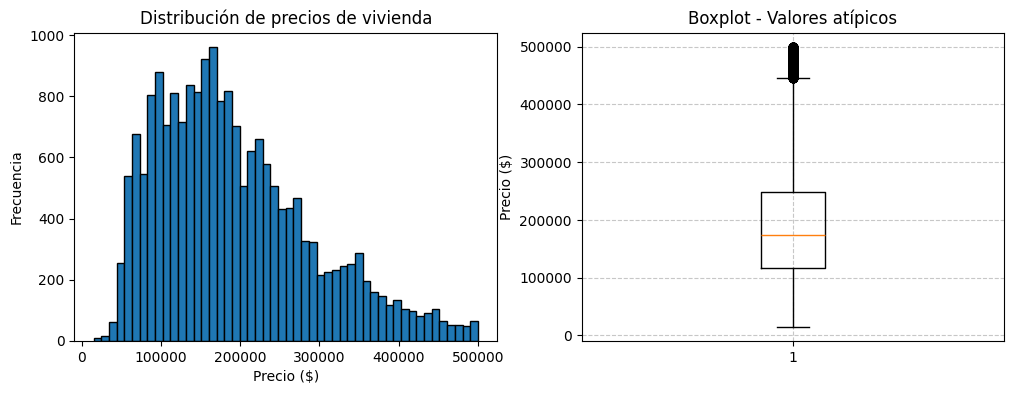

In [2]:
# Distribución de la variable objetivo
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(df_clean['median_house_value'], bins=50, edgecolor='black')
plt.title('Distribución de precios de vivienda')
plt.xlabel('Precio ($)')
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
plt.boxplot(df_clean['median_house_value'])
plt.title('Boxplot - Valores atípicos')
plt.grid(True, linestyle='--', alpha=0.7)
plt.ylabel('Precio ($)')

### Insights

__El rango de precios más común es de 150k, entre 150k y 250k. Se deduce del pico de frecuencia en el histograma, donde la altura de las barras es mayor entre 150,000 y 250,000.__

__Parece haber dos concentraciones:__
- La que ya hemos mencionado y la principal en el rango 150k–250k con alta frecuencia.
- Otra más pequeña posiblemente entre 350k–450k (segundo pico, aunque menos alto)

__Esto indicaría una distribución bimodal:__
- Viviendas económedias/asequibles
- Otro grupo de viviendas más caras

## 1.2 Análisis Bivariante Correlaciones

<Axes: >

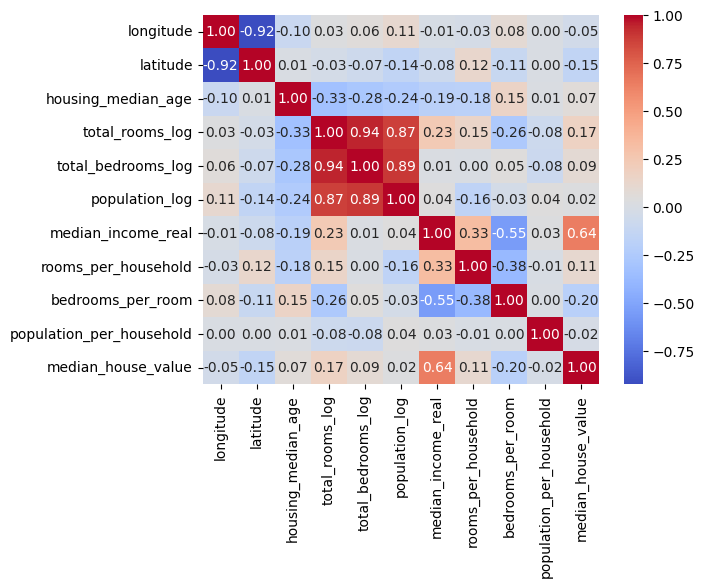

In [3]:
# Matriz de correlación con mapa de calor
corr_matrix = df_clean.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')

### Insights de negocio más relevantes cogiendo con __median_house_value__ como variable objetivo:

__1. El ingreso es el principal driver del valor de la vivienda.__

Correlación median_income_real vs median_house_value: +0.64 (fuerte positiva)

➡ Insight: Para aumentar el valor de una propiedad, la estrategia más efectiva es ubicarse en zonas de ingresos medios-altos.

➡ Acción: Segmentar el portafolio por nivel de ingreso del área y priorizar inversión en los cuadrantes de mayor ingreso.

__2. Habitaciones por hogar (rooms_per_household) tiene impacto positivo, aunque moderado.__

Correlación con valor de la vivienda: +0.11

➡ Insight: Tener más habitaciones por hogar ayuda, pero mucho menos que el ingreso. No es un diferenciador clave por sí solo.

__3. Dormitorios por habitación (bedrooms_per_room) correlaciona negativamente con el valor (-0.20).__

➡ Insight: Propiedades con muchas camas por habitación (hacinamiento o distribuciones ineficientes) tienden a valer menos.

➡ Acción: Evitar diseños con muchas habitaciones pequeñas o usos intensivos de dormitorios si se busca valor alto.

## 1.3 Análisis Geográfico (Spatial Analysis)

Text(0, 0.5, 'Latitud')

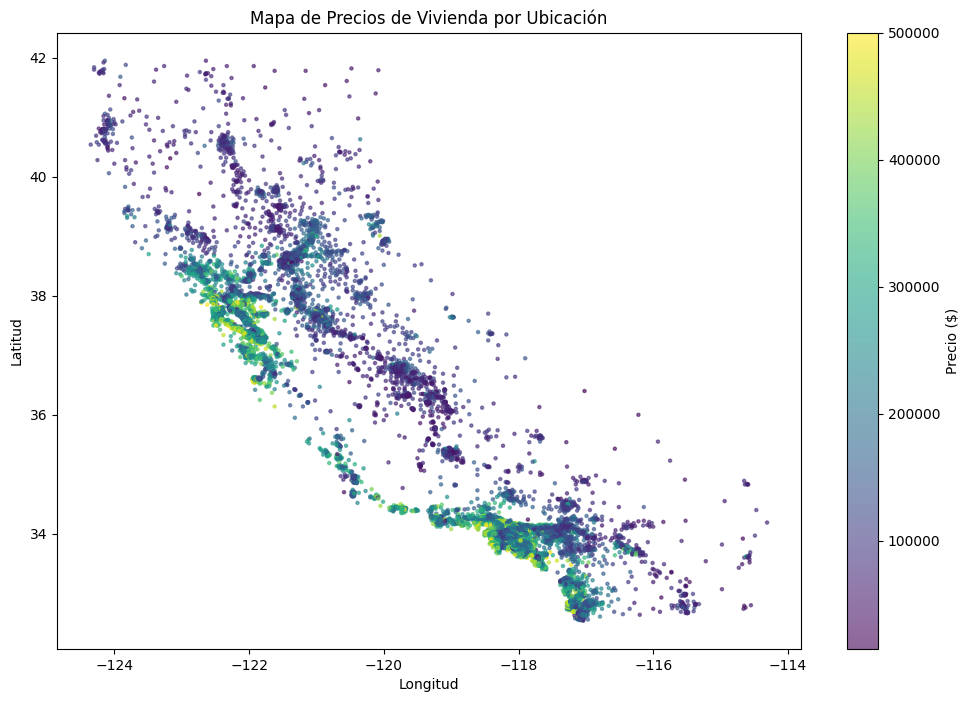

In [4]:
# Mapa de precios por ubicación
plt.figure(figsize=(12, 8))
scatter = plt.scatter(df_clean['longitude'], df_clean['latitude'], 
                      c=df_clean['median_house_value'], cmap='viridis', 
                      s=5, alpha=0.6)
plt.colorbar(scatter, label='Precio ($)')
plt.title('Mapa de Precios de Vivienda por Ubicación')
plt.xlabel('Longitud')
plt.ylabel('Latitud')

__Mapa de precios por ubicación directaemnte sobre el mapa usando la libreri ploty__

In [ ]:
import plotly.express as px

fig = px.scatter_map(
    df_clean,
    lat="latitude",
    lon="longitude",
    color="median_house_value",
    color_continuous_scale="viridis",
    zoom=5,
    opacity=0.5
)
fig.update_layout(
    title={
        'text': "Mapa de Precios de Vivienda en California",
        'x': 0.5,
        'xanchor': 'center',
        'font': {'size': 28}  
    }
)
fig.show()
fig.write_html("mapa_vivienda.html")

[Ver mapa de vivienda interactivo con __Ploty__ ](./mapa_vivienda.html)



## 1.4 Análisis de Proximidad al Océano

([0, 1, 2, 3],
 [Text(0, 0, 'NEAR BAY'),
  Text(1, 0, '<1H OCEAN'),
  Text(2, 0, 'INLAND'),
  Text(3, 0, 'NEAR OCEAN')])

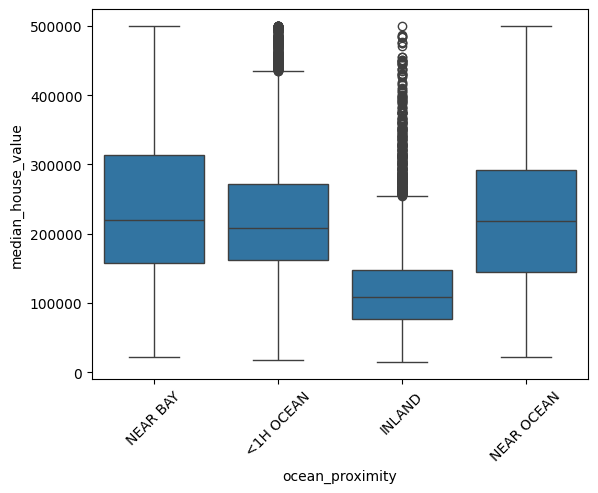

In [6]:
# Boxplot por categoría
sns.boxplot(data=df_clean, x='ocean_proximity', y='median_house_value')
plt.xticks(rotation=45)

## Gráfico resumen: Scatter coloreado por categoría (relación directa ingreso vs valor + geografía)

<Figure size 1200x800 with 0 Axes>

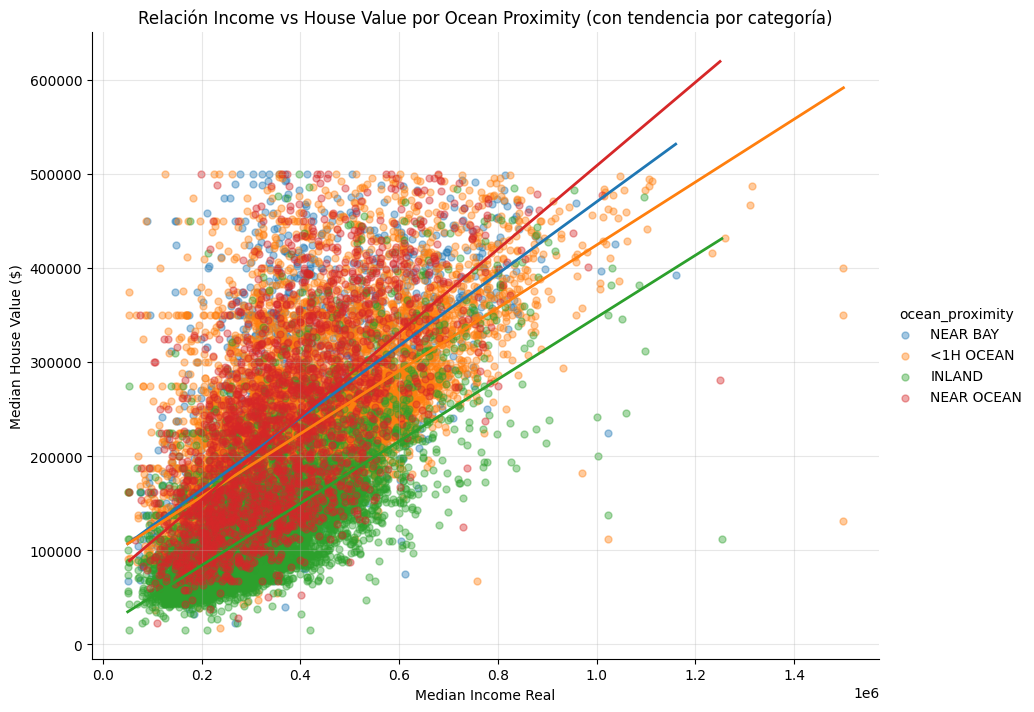

In [7]:
plt.figure(figsize=(12, 8))
sns.lmplot(
    data=df_clean,
    x='median_income_real',
    y='median_house_value',
    hue='ocean_proximity',
    scatter_kws={'alpha':0.4, 's':25},
    line_kws={'linewidth':2},
    height=7,
    aspect=1.3,
    ci=0  # Quita el intervalo de confianza para más claridad
)
plt.title('Relación Income vs House Value por Ocean Proximity (con tendencia por categoría)')
plt.xlabel('Median Income Real')
plt.ylabel('Median House Value ($)')
plt.grid(True, alpha=0.3)
plt.show()

### Insights de negocio más relevantes cogiendo con __ocean_proximity__ como variable objetivo:

__1. "NEAR BAY" es el segmento más premium (y el más estable)__

Insight: No solo es el barrio más caro, sino que los valores están altamente concentrados hacia arriba. El 75% de las casas cuestan más de $315,000.

Acción: Priorizar inversión aquí si se busca valor estable y alto con bajo riesgo de perder precio.

__2. "NEAR OCEAN" es el segundo mejor, pero con más cola baja__

Insight: Puedes encontrar gangas relativas (225k−225k−230k en percentiles bajos), pero el techo es casi igual al de NEAR BAY.

Acción: Ideal para oportunidades de flip o inversión con riesgo controlado.

__3. "INLAND" es el segmento de bajo valor (cuidado con el riesgo de cola)__

Insight: Es el mercado económico, pero el precio máximo está muy limitado.

Acción: Solo invertir aquí si el modelo de negocio es volumen alto o alquiler social, no para reventa premium.

__4. "<1H OCEAN" es el segmento más masivo y homogéneo__

Insight: Es la "clase media" del dataset. Valores estables pero sin el pico de NEAR BAY/OCEAN.

Acción: Bueno para inversión conservadora y diversificación geográfica.

### Conclusión ejecutiva

- __El ingreso es el factor #1.__
- __La proximidad al océano es un proxy geográfico de ese ingreso__

  - "Cerca de la Bahía = Ingreso alto + Valor estabilizado alto"
  - "Tierra Adentro = Ingreso bajo + Valor limitado"

### __Recomendación final:__

- 70% en NEAR BAY + NEAR OCEAN (apalancado en ingreso alto)

- 30% en <1H OCEAN (diversificación)

- Evitar INLAND salvo misión social o estrategia de volumen extremo.